# Convolutional and Recurrent Neural Networks

This notebook aims to convolutional and recurrent neural networks with practical examples in image and text classification problems.

Please:

* Make sure that you copy the entire folder to your Drive.
* Work in small groups (course assistants will join to help guide discussion!)
* Discuss your reasoning with each other.
* Write short answers in the markdown cells provided.

# Part 1: Image classification using Convolutional Neural Networks (CNNs)

**Discussion**


1.   What types of data have we looked at so far? Why might our previous models (e.g., logistic regression, simple MLP) not be the best choice for other types of data?
2. How would you handle e.g., image data with a simple MLP for classification?
3.   What are convolutional neural networks? What benefits might they have over the architectures we have previously discussed?

**Fun facts:** CNNs were originally proposed in 1989! Then there was a bit of an AI drought/winter until ~2012, when AlexNet [[Krizhevsky, Sutskever, & Hinton, 2012](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)] was proposed and won the ImageNet challenge! A crucial part of it was utilizing GPUs for training :)  

*Your answer here*

Let's start exploring CNNs in PyTorch by setting up the environment and importing the functional packages.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy

from google.colab import drive
drive.mount('/content/gdrive/')
import sys
sys.path.append('/content/gdrive/MyDrive/ML473/recitation/Lab9')
from plot_lib import plot_data, plot_model, set_default

set_default()

# function to count number of parameters
def get_n_params(model):
    np=0
    for p in list(model.parameters()):
        np += p.nelement()
    return np

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


If you have GPUs available PyTorch makes it particularly easy for us to make use of GPUs to speed up computation, so long as it can correctly find whether the GPU exists in the architecture or not.

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### Load the Dataset (MNIST)

The MNIST (Modified National Institute of Standards and Technology) database contains a large collection of images from handwritten digits, and it is one of the most commonly used machine learning evaluation benchmarks.

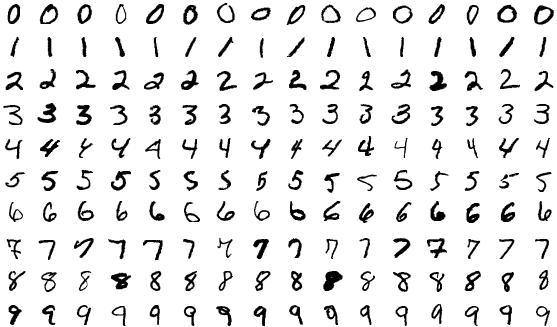

We can load the MNIST handwritten digits dataset using the PyTorch DataLoader utilities. After downloading, the program will shuffle, normalize data and arrange it in batches so they can appropriately be used in training the machine learning models.

Normalizing image data typically involves subtracting some coefficient (usually the mean) from each pixel values and dividing the resulting pixel values by another coefficient (usually the variance of the original pixel values).

In [4]:
input_size  = 28*28   # images are 28x28 pixels
output_size = 10      # there are 10 classes

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=1000, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 422kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.90MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


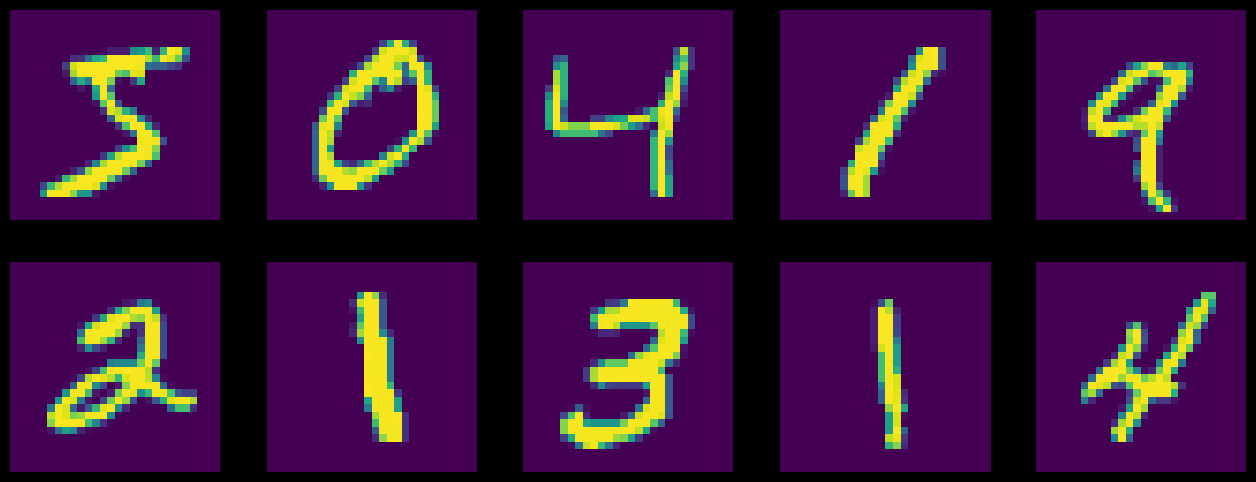

In [5]:
# Visualize some images from the database
plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    image, _ = train_loader.dataset.__getitem__(i)
    plt.imshow(image.squeeze().numpy())
    plt.axis('off');

### Create the model classes

In today's exercises we will create and demonstrate performance in image classification using two model classes:
1. Multi-layer Perceptron
2. Convolutional Neural Network

An important remark to remember specific to defining CNNs will be to pay special attention to the order of the layers.

Discussion:


1.   Why is the order of the layers important for CNNs?
2.  What is a convolution? How does it work?

*Your answer here*

In [6]:
class FC2Layer(nn.Module):
    def __init__(self, input_size, n_hidden, output_size):
        super(FC2Layer, self).__init__()
        self.input_size = input_size
        self.network = nn.Sequential(
            nn.Linear(input_size, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, output_size),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = x.view(-1, self.input_size)
        return self.network(x)

class CNN(nn.Module):
    def __init__(self, input_size, n_feature, output_size):
        super(CNN, self).__init__()
        self.n_feature = n_feature
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=n_feature, kernel_size=5)
        self.conv2 = nn.Conv2d(n_feature, n_feature, kernel_size=5)
        self.fc1 = nn.Linear(n_feature*4*4, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x, verbose=False):
        x = self.conv1(x)
        x = F.relu(x) # Will it make a difference if we apply the non-linearity after the pooling layer?
        x = F.max_pool2d(x, kernel_size=2)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        x = x.view(-1, self.n_feature*4*4) # this is where are flattening the 2D feature maps into a single 1D vector so as to be used by the subsequent fully connected layer
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.log_softmax(x, dim=1)
        return x

### Running on a GPU: device string

Switching between CPU and GPU in PyTorch is controlled via a device string, which will seamlessly determine whether GPU is available, falling back to CPU if not:

In [7]:
accuracy_list = []
def train(epoch, model, perm=torch.arange(0, 784).long()):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # send data to device, where the "device" is either a GPU if it exists or a CPU
        data, target = data.to(device), target.to(device)

        # permute pixels
        data = data.view(-1, 28*28)
        data = data[:, perm]
        data = data.view(-1, 1, 28, 28)

        optimizer.zero_grad()
        # forward pass through the model
        output = model(data)
        # forward pass through the cross-entropy loss function
        loss = F.nll_loss(output, target)
        # backward pass through the cross-entropy loss function and the model
        loss.backward()

        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

def test(model, perm=torch.arange(0, 784).long()):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            # send data to device, where the "device" is either a GPU if it exists or a CPU
            data, target = data.to(device), target.to(device)

            # permute pixels
            data = data.view(-1, 28*28)
            data = data[:, perm]
            data = data.view(-1, 1, 28, 28)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item() # sum up batch loss
            pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
            correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()

        test_loss /= len(test_loader.dataset)
        accuracy = 100. * correct / len(test_loader.dataset)
        accuracy_list.append(accuracy)
        print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
            test_loss, correct, len(test_loader.dataset),
            accuracy))

### Train a small MLP

In [8]:
n_hidden = 8 # number of hidden units

model_fnn = FC2Layer(input_size, n_hidden, output_size)
model_fnn.to(device)
optimizer = optim.SGD(model_fnn.parameters(), lr=0.01, momentum=0.5)
print('Number of parameters: {}'.format(get_n_params(model_fnn)))

for epoch in range(0, 1):
    train(epoch, model_fnn)
    test(model_fnn)

Number of parameters: 6442
Train Epoch: 0 [0/60000 (0%)]	Loss: 2.372073
Train Epoch: 0 [6400/60000 (11%)]	Loss: 1.814778
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.266296
Train Epoch: 0 [19200/60000 (32%)]	Loss: 0.793859
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.679203
Train Epoch: 0 [32000/60000 (53%)]	Loss: 0.615813
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.472336
Train Epoch: 0 [44800/60000 (75%)]	Loss: 0.325022
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.414838
Train Epoch: 0 [57600/60000 (96%)]	Loss: 0.389692

Test set: Average loss: 0.3731, Accuracy: 8958/10000 (90%)



### Train a CNN with the same number of parameters

Make sure to clarify your understanding on how the model works by changing the hyper-parameters and observing their relationship with model performance.

In [9]:
# Training settings
n_features = 6 # number of feature maps

model_cnn = CNN(input_size, n_features, output_size)
model_cnn.to(device)
optimizer = optim.SGD(model_cnn.parameters(), lr=0.01, momentum=0.5)
print('Number of parameters: {}'.format(get_n_params(model_cnn)))

for epoch in range(0, 1):
    train(epoch, model_cnn)
    test(model_cnn)

Number of parameters: 6422
Train Epoch: 0 [0/60000 (0%)]	Loss: 2.308858
Train Epoch: 0 [6400/60000 (11%)]	Loss: 2.131001
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.582831
Train Epoch: 0 [19200/60000 (32%)]	Loss: 0.345349
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.305222
Train Epoch: 0 [32000/60000 (53%)]	Loss: 0.198941
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.156944
Train Epoch: 0 [44800/60000 (75%)]	Loss: 0.270534
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.255424
Train Epoch: 0 [57600/60000 (96%)]	Loss: 0.228846

Test set: Average loss: 0.1689, Accuracy: 9502/10000 (95%)



**Discussion**


1.   Which of the two models performs better? Why? What does the use of convolution address? What about pooling?
2.   What do you think would happen if these assumptions are no longer true?


*Your answer here*


### Exercise: What happens if the assumptions are no longer true?

Let us break the assumption of locality and permute the pixel within each image using an arbitrary permutation matrix. We can visualize the experiment by displaying the permuted images.

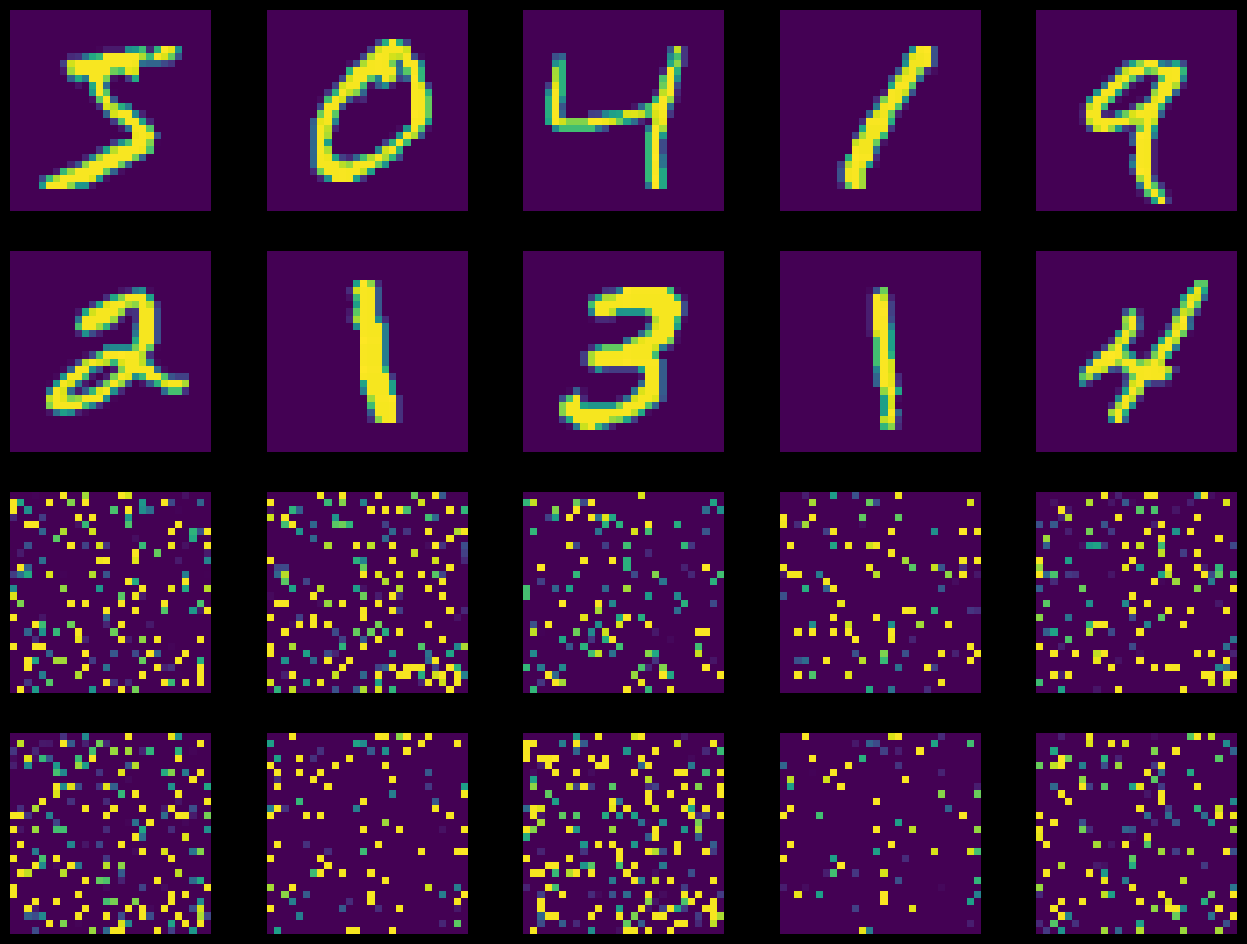

In [10]:
torch.manual_seed(1)
perm = torch.randperm(784)
plt.figure(figsize=(16, 12))
for i in range(10):
    image, _ = train_loader.dataset.__getitem__(i)
    # permute pixels
    image_perm = image.view(-1, 28*28).clone()
    image_perm = image_perm[:, perm]
    image_perm = image_perm.view(-1, 1, 28, 28)
    plt.subplot(4, 5, i + 1)
    plt.imshow(image.squeeze().numpy())
    plt.axis('off')
    plt.subplot(4, 5, i + 11)
    plt.imshow(image_perm.squeeze().numpy())
    plt.axis('off')

### CNNs with permuted pixels
What do you think will happen to CNNs when given permuted pixels as inputs?

In [12]:
# To-do: repeat training of CNN
# by passing permutation function 'perm' into training function
import torch
import torchvision
from torchvision import datasets, transforms

# Fixed pixel permutation (same for train & test)
torch.manual_seed(1)
perm = torch.randperm(28 * 28)

# Shape-preserving permutation transform for (B,1,28,28)
class PermutePixels(torch.nn.Module):
    def __init__(self, perm):
        super().__init__()
        self.register_buffer("perm", perm.clone())
    def forward(self, x):
        B = x.size(0)
        x = x.view(B, -1)[:, self.perm]      # apply permutation on flattened pixels
        return x.view(B, 1, 28, 28)
perm_transform = PermutePixels(perm)



In [13]:
input_size  = 28*28
output_size = 10

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])),
    batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])),
    batch_size=1000, shuffle=False)   # ← better to keep test deterministic


In [14]:
train_loader_perm = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            perm_transform,
            transforms.Normalize((0.1307,), (0.3081,))
        ])),
    batch_size=64, shuffle=True)

test_loader_perm = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False,
        transform=transforms.Compose([
            transforms.ToTensor(),
            perm_transform,
            transforms.Normalize((0.1307,), (0.3081,))
        ])),
    batch_size=1000, shuffle=False)


In [15]:
def train_one_model(model, train_loader_x, test_loader_x, epochs=1, lr=0.01, mom=0.5):
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=mom)
    print('Number of parameters:', get_n_params(model))
    for ep in range(epochs):
        train(ep, model, train_loader_x, optimizer)
    acc = test(model, test_loader_x)   # make sure test() returns accuracy
    return acc

accs = {}

# 1) MLP on normal images
model_fnn = FC2Layer(input_size, n_hidden=8, output_size=output_size).to(device)
accs['NN image'] = train_one_model(model_fnn, train_loader, train_loader and test_loader)

# 2) CNN on normal images
model_cnn = CNN(input_size, n_features=6, output_size=output_size).to(device)
accs['CNN image'] = train_one_model(model_cnn, train_loader, test_loader)

# 3) CNN on permuted images
model_cnn_scr = CNN(input_size, n_features=6, output_size=output_size).to(device)
accs['CNN scrambled'] = train_one_model(model_cnn_scr, train_loader_perm, test_loader_perm)

# 4) MLP on permuted images
model_fnn_scr = FC2Layer(input_size, n_hidden=8, output_size=output_size).to(device)
accs['NN scrambled'] = train_one_model(model_fnn_scr, train_loader_perm, test_loader_perm)

print(accs)


Number of parameters: 6442


TypeError: train() takes from 2 to 3 positional arguments but 4 were given

### MLPs with permuted pixels

In [ ]:
# To-do: Repeat training of MLP
# by passing permutation function 'perm' into training function



ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (2,).

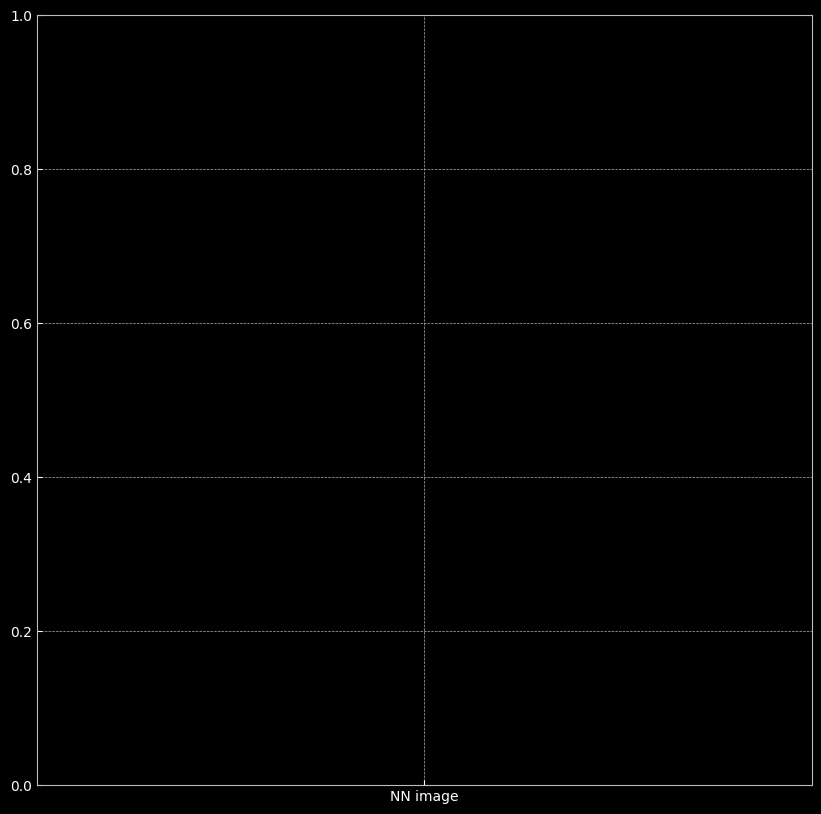

In [16]:
plt.bar(('NN image', 'CNN image',
         'CNN scrambled', 'NN scrambled'),
        accuracy_list, width=0.4)
plt.ylim((min(accuracy_list)-5, 96))
plt.ylabel('Accuracy [%]')
for tick in plt.gca().xaxis.get_major_ticks():
    tick.label.set_fontsize(20)
plt.title('Performance comparison');

**Discussion**


1.   What happens to the CNN performance? What about the fully-connected network?
2.   Explain why this happens!

*Your answer here*

# (Optional) Part 2: Text classification using Recurrent Neural Networks (RNNs)

Now, what are some other data types that we are missing? Text and other sequential data! These ideas are the backbones powering the powerful transformer models of today!

In this lab, we will look at RNNs. An RNN is a type of neural network used to process sequential data by maintaining a hidden state across time steps. Today, we will just be looking at classification with RNNs. Our classification task will involve automatically labeling the sentiment of movie reviews. For building our model we will use the [Large Movie Review Dataset](https://keras.io/api/datasets/imdb/).

**History:** Seq2seq (precursor to transformer) [[Sutskever, Vinyals, & Le, 2014](https://arxiv.org/abs/1409.3215)] is the architecture that uses (often two) RNNs---one encoder and one decoder---to transform one sequence into another. But compressing all input information into a single vector created an information bottleneck, which was solved with attention [[Bahdanau, Cho, & Bengio, 2015](https://arxiv.org/abs/1409.0473)] by allowing the decoder to dynamically focus on relevant parts of the input at each step. Finally, the transformer [[Vaswani, et al., 2018](https://arxiv.org/abs/1706.03762)] removed recurrence entirely! This architecture underpins nearly all modern large language and vision models.



### Dataset Exploration

Let's load the review data and see how the input and labels look like.

In [18]:
!pip install torchtext==0.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.0 MB/s eta 0:00:00


In [19]:
import torch
from torchtext import data

TEXT = data.Field(tokenize = 'spacy',
                  tokenizer_language = 'en_core_web_sm')
LABEL = data.LabelField(dtype = torch.float)

In [20]:
from torchtext import datasets

train_data, test_data = datasets.IMDB.splits(TEXT, LABEL)

print(f'Number of training examples: {len(train_data)}')
print(f'Number of testing examples: {len(test_data)}')

downloading aclImdb_v1.tar.gz


aclImdb_v1.tar.gz: 100%|██████████| 84.1M/84.1M [00:02<00:00, 41.1MB/s]


Number of training examples: 25000
Number of testing examples: 25000


We can inspect the samples from the data set using the training and testing sets.

In [21]:
print(vars(train_data.examples[0]))

{'text': ['Enjoyed', 'the', 'movie', 'very', 'much', '.', 'Certainly', 'will', 'leave', 'the', 'audience', 'wanting', 'to', 'know', 'more', ',', 'and', 'there', 'is', 'truly', 'a', 'lot', 'more', 'historically', 'to', 'find', 'out!<br', '/><br', '/>Did', 'the', 'production', 'team', 'fall', 'to', 'the', 'temptation', 'of', 'over', 'dramatization', ',', 'particularly', 'of', 'the', 'shooting', 'event', '?', 'There', 'is', 'a', 'ton', 'of', 'interesting', 'accurate', 'material', 'hinted', 'at', '?', 'Prince', 'Albert', "'s", 'contribution', 'to', 'UK', 'and', 'the', 'monarchy', 'warrants', 'a', 'movie', 'on', 'it', "'s", 'own', 'but', 'granted', 'that', 'was', 'apparently', 'not', 'part', 'of', 'the', 'intention', 'here.<br', '/><br', '/>The', 'costumes', 'and', 'sets', 'are', 'especially', 'good', 'but', 'am', 'I', 'alone', 'in', 'thinking', 'that', 'this', 'production', '(', 'which', 'judging', 'by', 'the', 'length', 'of', 'titles', 'at', 'the', 'end', 'was', 'certainly', 'not', 'a', '

To process the input we will first represent each word in terms of a number, identifying it in the English vocabulary. We will build a vocabulary and convert each word to a unique number using the training data set.


In [ ]:
TEXT.build_vocab(train_data, max_size=5000)
LABEL.build_vocab(train_data)

# Let's see what the top 10 words in the vocabulary are
print(TEXT.vocab.freqs.most_common(10))

Finally, for representing our training data in batches, we will create iterators as we did in previous recitations.

In [17]:
BATCH_SIZE = 32

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, test_data),
    batch_size = BATCH_SIZE,
    device = device)

NameError: name 'data' is not defined

### Define the Model

**Discussion**

1.   What is missing from the previous models that would make language processing challenging?
2.   What is a recurrent neural network? How does it differ from e.g., a fully-connected MLP?

*Your answer here*

In [ ]:
import torch
import torch.nn as nn

# Set the random seed for reproducible results
torch.manual_seed(1)

class SimpleRNN(nn.Module):
    def __init__(self, input_size, embedding_size, hidden_size, output_size):
        # This just calls the base class constructor
        super().__init__()
        # Neural network layers assigned as attributes of a Module subclass
        # have their parameters registered for training automatically.
        self.embedding = nn.Embedding(input_size, embedding_size)
        self.rnn = torch.nn.RNN(embedding_size, hidden_size)
        self.linear = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # The RNN also returns its hidden state but we don't use it.
        # While the RNN can also take a hidden state as input, the RNN
        # gets passed a hidden state initialized with zeros by default.
        w = self.embedding(x)
        o, h = self.rnn(w)
        return self.linear(h.squeeze(0))


In [ ]:
input_size = len(TEXT.vocab)
embedding_size = 50
hidden_size = 50
output_size = 1

model = SimpleRNN(input_size, embedding_size, hidden_size, output_size)

### Training Loop

In [ ]:
from sklearn.metrics import accuracy_score

def train(model, criterion, optimizer, iterator):

    epoch_loss = 0
    epoch_acc = 0

    # Set the model to training mode. This will turn on layers that would
    # otherwise behave differently during evaluation, such as dropout.
    model.train()

    # Store the number of sequences that were classified correctly
    num_correct = 0

    # Iterate over every batch of sequences. Note that the length of a data generator
    # is defined as the number of batches required to produce a total of roughly 1000
    # sequences given a batch size.
    for batch in iterator:

        preds = model(batch.text).squeeze(1)
        loss = criterion(preds, batch.label)

        rounded_preds = torch.round(torch.sigmoid(preds))

        preds_np = rounded_preds.detach()
        labels_np = batch.label.detach()
        acc = accuracy_score(preds_np, labels_np)

        # the backward pass over the loss and the model
        loss.backward()

        # the gradient step to update the weights
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

        # Clear the gradient buffers of the optimized parameters.
        # Otherwise, gradients from the previous batch would be accumulated.
        optimizer.zero_grad()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

### Testing Loop

In [ ]:
def evaluate(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for batch in iterator:

            preds = model(batch.text).squeeze(1)
            loss = criterion(preds, batch.label)

            rounded_preds = torch.round(torch.sigmoid(preds))
            acc = accuracy_score(rounded_preds, batch.label)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [22]:
import torch.optim as optim

epochs = 5
learning_rate = 1e-3

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss()
model = model.to(device)
criterion = criterion.to(device)

for epoch in range(epochs):

    train_loss, train_acc = train(model, criterion, optimizer, train_iterator)

    print(f'Epoch: {epoch+1:02} | \tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')


NameError: name 'model' is not defined

## Further references:

- Students interested in studying deep learning methods more in depth can refer to the [Deep Learning](https://www.deeplearningbook.org/) book available online.